<div style="
    background: linear-gradient(45deg,
        #d6eaf8,
        #f2f4f4 20%,
        #ffe5b4 40%,
        #ffffcc 60%,
        #d1f2eb 80%,
        #f3e5f5 100%
    );
    padding: 20px;
    margin: 20px 0;
    border-radius: 10px;
    box-shadow: 5px 5px 15px rgba(0, 0, 0, 0.3);
    font-family: Arial, sans-serif;
    color: #1a1a1a;
    font-weight: bold;
    text-align: center;
">
<h2><strong>Santoki Het</strong></h2>
</div>

<div style="
    background: linear-gradient(45deg,
        #d6eaf8,
        #f2f4f4 20%,
        #ffe5b4 40%,
        #ffffcc 60%,
        #d1f2eb 80%,
        #f3e5f5 100%
    );
    padding: 20px;
    margin: 20px 0;
    border-radius: 10px;
    box-shadow: 5px 5px 15px rgba(0, 0, 0, 0.3);
    font-family: Arial, sans-serif;
    color: #1a1a1a;
    font-weight: bold;
    text-align: center;
">
<h1><strong>Problem Statement </strong></h1>
<p>A retail / e-commerce business doesn't know how much stock to order in advance.
</p>
<p>If they order too little → stockout (product runs out, sales lost, customer unhappy).
If they order too much → overstock (money locked in unsold inventory, storage cost).
Right now they guess based on gut feeling or simple averages. That works okay in normal weeks — but fails completely during festivals, holidays, and seasonal spikes when demand suddenly jumps 3–5x.</p>
</div>

<div style="
    background: linear-gradient(45deg,
        #d6eaf8,
        #f2f4f4 20%,
        #ffe5b4 40%,
        #ffffcc 60%,
        #d1f2eb 80%,
        #f3e5f5 100%
    );
    padding: 20px;
    margin: 20px 0;
    border-radius: 10px;
    box-shadow: 5px 5px 15px rgba(0, 0, 0, 0.3);
    font-family: Arial, sans-serif;
    color: #1a1a1a;
    font-weight: bold;
    text-align: center;
">
<h1><strong>Objectives </strong></h1>
<ol>
    <li>
        <p>
        <strong>Clean and preprocess 500K+ retail transactions.</strong>
        </p>
    </li>
    <li>
        <p>
        <strong>Analyze demand patterns through EDA.</strong>
        </p>
    </li>
    <li>
        <p>
        <strong>Decompose time-series into trend, seasonality, and noise.</strong>
        </p>
    </li>
    <li>
        <p>
        <strong>Engineer lag, rolling, and calendar-based features.</strong>
        </p>
    </li>
    <li>
        <p>
        <strong>Build and compare ML models — Linear Regression, Random Forest, XGBoost.</strong>
        </p>
    </li>
    <li>
        <p>
        <strong>Evaluate models using MAE, RMSE, and MAPE.</strong>
        </p>
    </li>
    <li>
        <p>
        <strong>Model festival and seasonal impact on demand.</strong>
        </p>
    </li>
    <li>
        <p>
        <strong>Deploy forecast results via a Django dashboard.</strong>
        </p>
    </li>
</ol>
</div>









<div style="
    background: linear-gradient(45deg,
        #d6eaf8,
        #f2f4f4 20%,
        #ffe5b4 40%,
        #ffffcc 60%,
        #d1f2eb 80%,
        #f3e5f5 100%
    );
    padding: 20px;
    margin: 20px 0;
    border-radius: 10px;
    box-shadow: 5px 5px 15px rgba(0, 0, 0, 0.3);
    font-family: Arial, sans-serif;
    color: #1a1a1a;
    font-weight: bold;
    text-align: center;
">
<h2><strong>Goals </strong></h2>
<ol>
    <li>
        <p>
        <strong>Predict future product demand accurately using historical sales data.</strong>
        </p>
    </li>
    <li>
        <p>
        <strong>Identify seasonal and festival-driven demand spikes before they happen.</strong>
        </p>
    </li>
    <li>
        <p>
        <strong>Prevent stockouts by alerting when inventory is likely to run short.</strong>
        </p>
    </li>
</ol>
</div>




<div style="
    background: linear-gradient(45deg,
        #d6eaf8 0%,
        #d6eaf8 10%,
        #f2f4f4 10%,
        #f2f4f4 20%,
        #ffe5b4 20%,
        #ffe5b4 30%,
        #ffffcc 30%,
        #ffffcc 40%,
        #d1f2eb 40%,
        #d1f2eb 50%,
        #f3e5f5 50%,
        #f3e5f5 60%,
        #ffe4e1 60%,
        #ffe4e1 70%
    );
    color: #1a1a1a;
    font-weight: bold;
    text-align: center;
    padding: 10px;
    box-shadow: 5px 5px 15px rgba(0, 0, 0, 0.3);
    border-radius: 10px;
">
    <h2><strong>Step 1 - Importing Libraries</strong></h2>
</div>

In [31]:
# ── Data handling ──────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── ML Models ──────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ── Model evaluation ───────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# ── Model saving ───────────────────────────────────────────
import joblib

# ── Miscellaneous ──────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ───────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)


In [32]:
df = pd.read_csv("../Data/data.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [33]:
print("Shape:", df.shape)

Shape: (541909, 8)


In [34]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custome

In [35]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [36]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [37]:
# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove cancelled orders (InvoiceNo starts with 'C')
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Cancelled orders removed: {len(cancelled)}")

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Rows remaining: {len(df)}")

Cancelled orders removed: 9288
Rows remaining: 532621


In [38]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df = df.dropna(subset=['CustomerID'])

In [39]:
df.shape

(397884, 8)

In [40]:
df['Revenue']    = df['Quantity'] * df['UnitPrice']
df['Date']       = df['InvoiceDate'].dt.date
df['Year']       = df['InvoiceDate'].dt.year
df['Month']      = df['InvoiceDate'].dt.month
df['Week']       = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['DayOfWeek']  = df['InvoiceDate'].dt.dayofweek

print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
print(df[['Date', 'Year', 'Month', 'Week', 'DayOfWeek', 'Revenue']].head())

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
         Date  Year  Month  Week  DayOfWeek  Revenue
0  2010-12-01  2010     12    48          2    15.30
1  2010-12-01  2010     12    48          2    20.34
2  2010-12-01  2010     12    48          2    22.00
3  2010-12-01  2010     12    48          2    20.34
4  2010-12-01  2010     12    48          2    20.34


In [41]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Year,Month,Week,DayOfWeek
count,397884.000000,397884,397884.000000,397884.000000,397884.000000,397884.000000,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000,2010.934260,7.612475,30.964361,2.614546
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000,2011.000000,5.000000,19.000000,1.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000,2011.000000,8.000000,34.000000,2.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000,2011.000000,11.000000,44.000000,4.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,51.000000,6.000000
std,179.331775,NaN,22.097877,1713.141560,309.071041,0.247828,3.416520,14.755843,1.928310


In [42]:
daily_demand = df.groupby('Date').agg(
    TotalQuantity   = ('Quantity', 'sum'),
    TotalRevenue    = ('Revenue', 'sum'),
    NumTransactions = ('InvoiceNo', 'nunique')
).reset_index()

daily_demand['Date'] = pd.to_datetime(daily_demand['Date'])
daily_demand = daily_demand.sort_values('Date')

full_range = pd.date_range(
    start=daily_demand['Date'].min(),
    end=daily_demand['Date'].max(),
    freq='D'
)

daily_demand = daily_demand.set_index('Date').reindex(full_range, fill_value=0)
daily_demand.index.name = 'Date'

print("Daily demand shape:", daily_demand.shape)
print(daily_demand.head(10))

Daily demand shape: (374, 3)
            TotalQuantity  TotalRevenue  NumTransactions
Date                                                    
2010-12-01          24215      46376.49              121
2010-12-02          31142      47316.53              137
2010-12-03          11839      23921.71               57
2010-12-04              0          0.00                0
2010-12-05          16449      31771.60               87
2010-12-06          16291      31215.64               94
2010-12-07          19444      53795.31               71
2010-12-08          21573      39248.82              111
2010-12-09          17415      38231.90               98
2010-12-10          16051      33650.28               72


In [43]:
df.to_csv('../data/cleaned_transactions.csv', index=False)
daily_demand.to_csv('../data/daily_demand.csv')

print(f"\nFinal clean rows : {len(df):,}")
print(f"Daily series days: {len(daily_demand)}")


Final clean rows : 397,884
Daily series days: 374


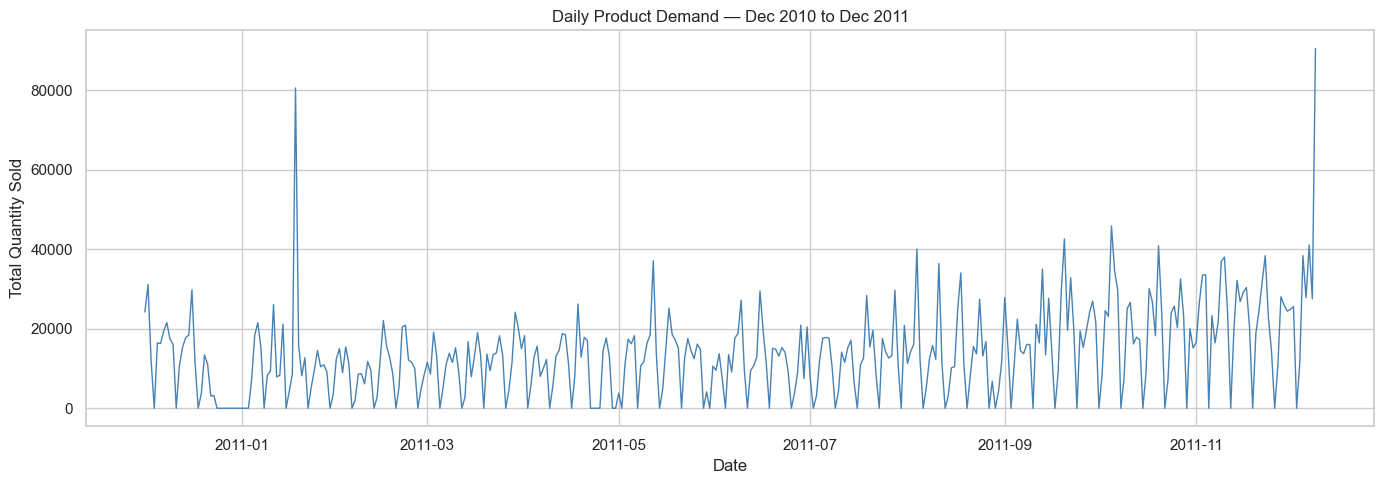

In [44]:
plt.figure(figsize=(14, 5))
plt.plot(daily_demand.index, daily_demand['TotalQuantity'], color='steelblue', linewidth=1)
plt.title('Daily Product Demand — Dec 2010 to Dec 2011')
plt.xlabel('Date')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

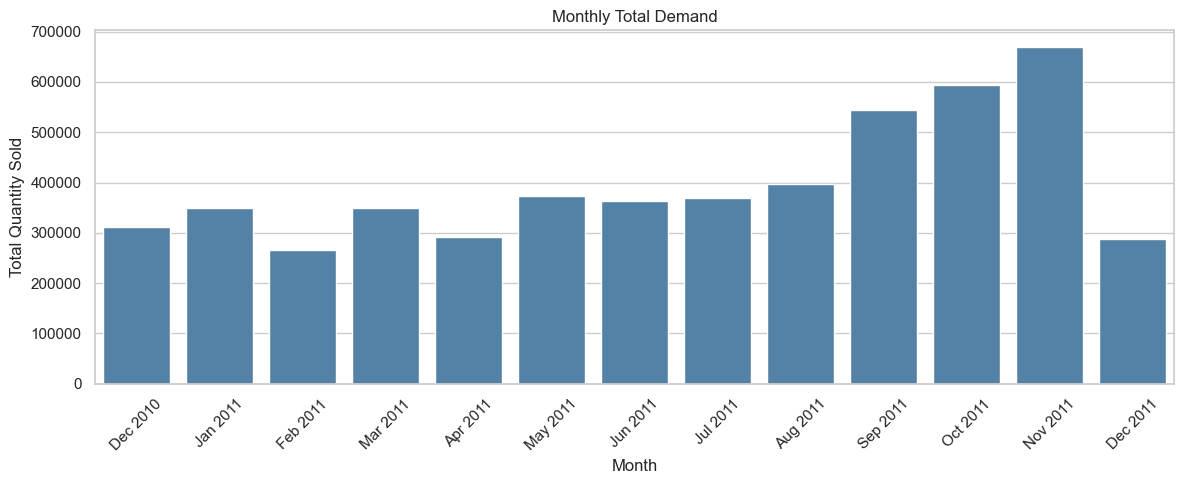

In [45]:
monthly = daily_demand['TotalQuantity'].resample('M').sum()

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly.index.strftime('%b %Y'), y=monthly.values, color='steelblue')
plt.title('Monthly Total Demand')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

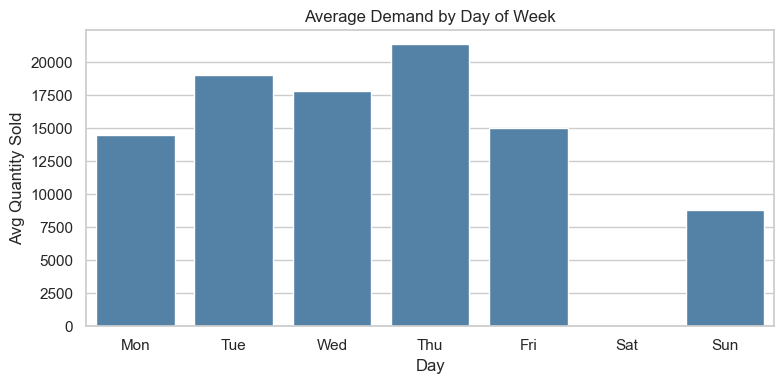

In [46]:
daily_demand['DayOfWeek'] = daily_demand.index.dayofweek

dow = daily_demand.groupby('DayOfWeek')['TotalQuantity'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(8, 4))
sns.barplot(x=days, y=dow.values, color='steelblue')
plt.title('Average Demand by Day of Week')
plt.xlabel('Day')
plt.ylabel('Avg Quantity Sold')
plt.tight_layout()
plt.show()

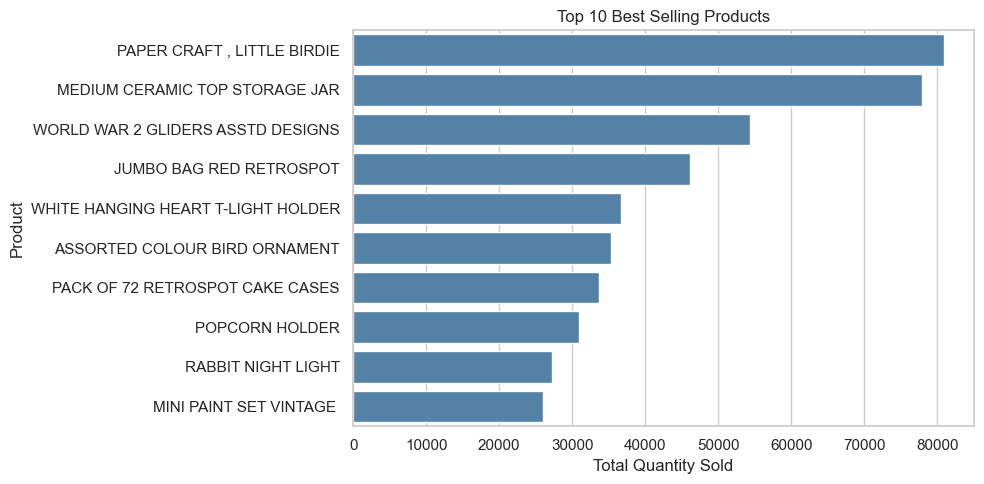

In [47]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index, color='steelblue')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

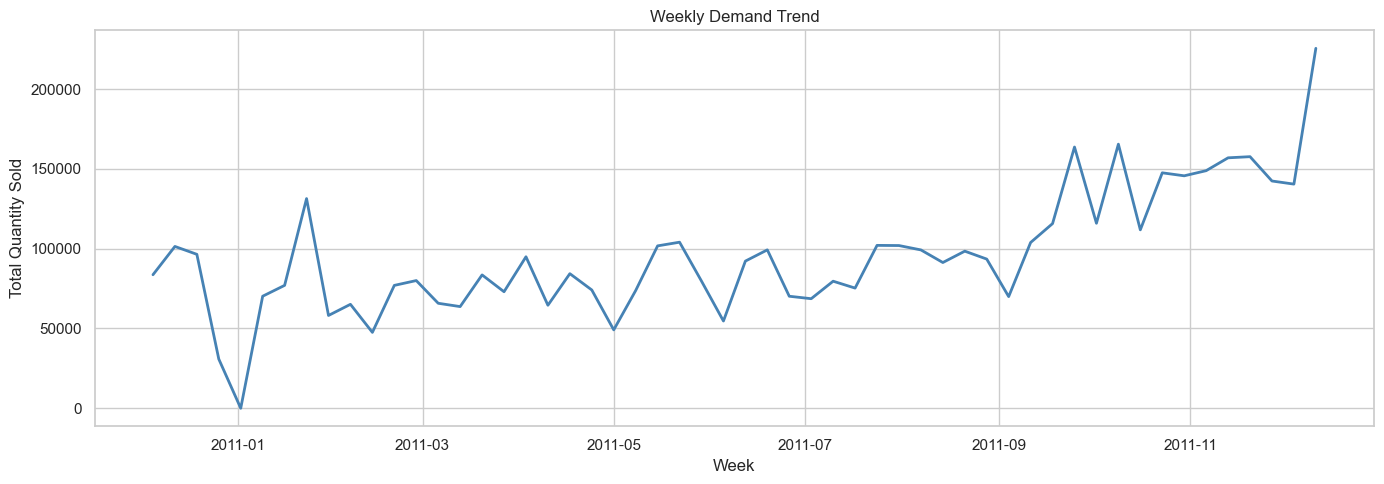

In [48]:
weekly = daily_demand['TotalQuantity'].resample('W').sum()

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly.values, color='steelblue', linewidth=2)
plt.title('Weekly Demand Trend')
plt.xlabel('Week')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

## Key EDA Findings

1. Demand peaks in Nov–Dec due to Christmas season
2. Thursday is the busiest trading day; Saturday store is closed
3. Q4 (Sep–Dec) accounts for the highest demand of the year
4. Two extreme spikes detected — Jan & Dec 2011 (bulk orders)
5. Top product: PAPER CRAFT, LITTLE BIRDIE (~80K units sold)
6. Clear upward growth trend across the year

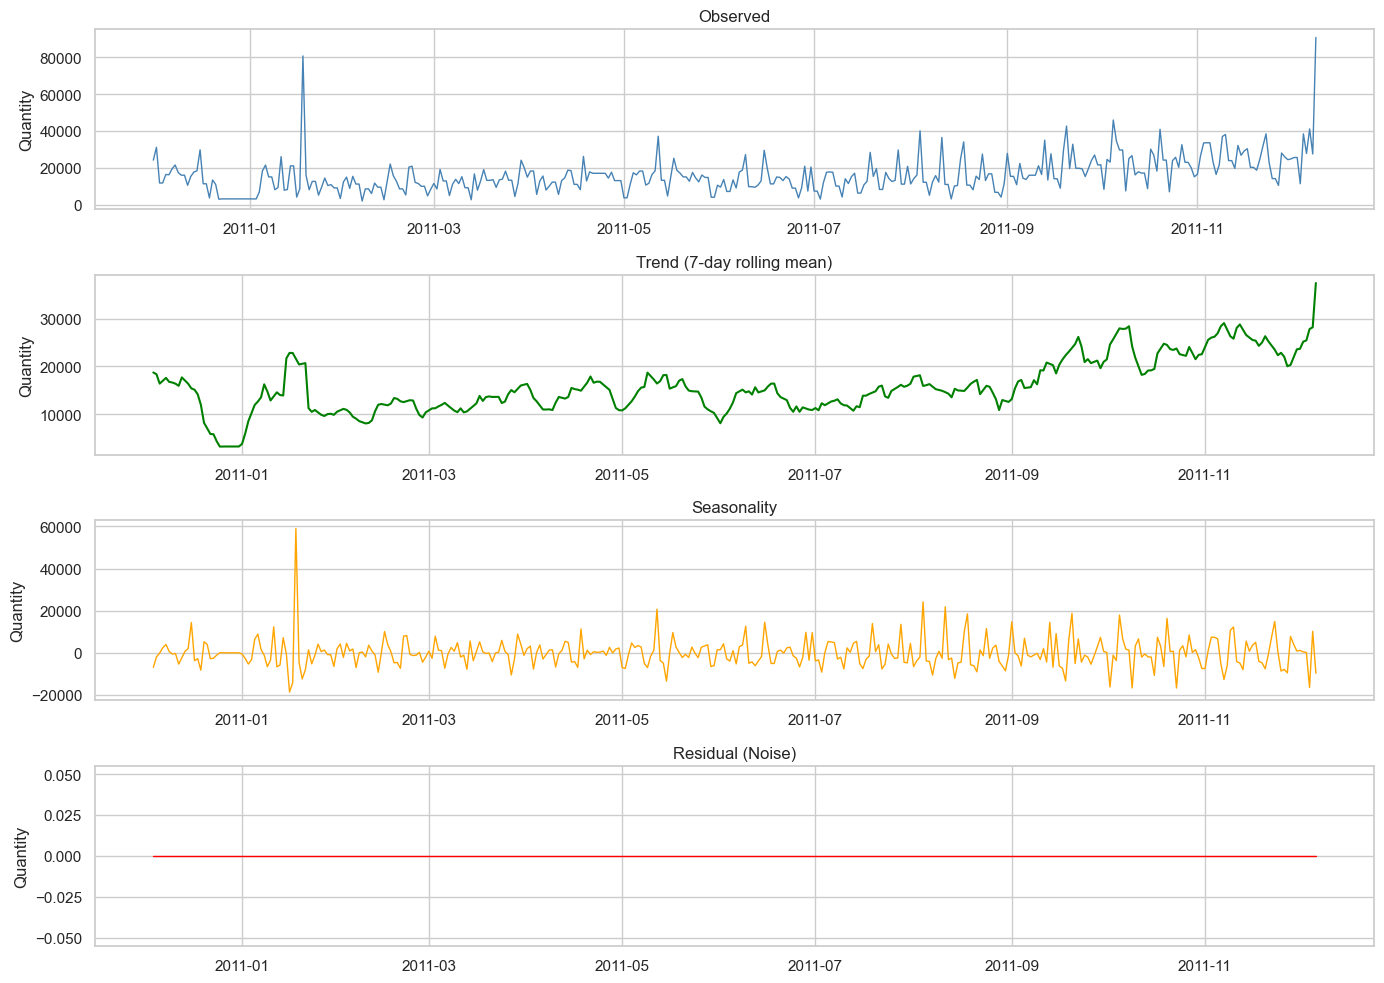

In [ ]:
demand_series = daily_demand['TotalQuantity'].replace(0, np.nan).ffill()

# Trend — 7 day rolling average
trend = demand_series.rolling(window=7, center=True).mean()

# Seasonality — difference between actual and trend
seasonality = demand_series - trend

# Residual — what's left after removing trend and seasonality
residual = demand_series - trend - seasonality

# Plot
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(demand_series.index, demand_series.values, color='steelblue', linewidth=1)
axes[0].set_title('Observed')
axes[0].set_ylabel('Quantity')

axes[1].plot(trend.index, trend.values, color='green', linewidth=1.5)
axes[1].set_title('Trend (7-day rolling mean)')
axes[1].set_ylabel('Quantity')

axes[2].plot(seasonality.index, seasonality.values, color='orange', linewidth=1)
axes[2].set_title('Seasonality')
axes[2].set_ylabel('Quantity')

axes[3].plot(residual.index, residual.values, color='red', linewidth=1)
axes[3].set_title('Residual (Noise)')
axes[3].set_ylabel('Quantity')

plt.tight_layout()
plt.show()

In [50]:
# Work on a copy
data = daily_demand.copy()

# Lag features — demand from N days ago
# Why? Yesterday's sales is a strong predictor of today's sales
data['Lag_1']  = data['TotalQuantity'].shift(1)
data['Lag_7']  = data['TotalQuantity'].shift(7)
data['Lag_14'] = data['TotalQuantity'].shift(14)
data['Lag_30'] = data['TotalQuantity'].shift(30)

# Rolling average features — smoothed demand
# Why? Captures short and medium term demand trends
data['Rolling_7']  = data['TotalQuantity'].shift(1).rolling(7).mean()
data['Rolling_14'] = data['TotalQuantity'].shift(1).rolling(14).mean()
data['Rolling_30'] = data['TotalQuantity'].shift(1).rolling(30).mean()

# Calendar features
data['DayOfWeek'] = data.index.dayofweek
data['Month']     = data.index.month
data['Week']      = data.index.isocalendar().week.astype(int)
data['IsWeekend'] = (data['DayOfWeek'] >= 5).astype(int)
data['Quarter']   = data.index.quarter

# Drop rows with NaN created by lag/rolling
data = data.dropna()

print("Feature engineered dataset shape:", data.shape)
print(data.head())

Feature engineered dataset shape: (344, 15)
            TotalQuantity  TotalRevenue  NumTransactions  DayOfWeek  Lag_1  \
Date                                                                         
2010-12-31              0          0.00                0          4    0.0   
2011-01-01              0          0.00                0          5    0.0   
2011-01-02              0          0.00                0          6    0.0   
2011-01-03              0          0.00                0          0    0.0   
2011-01-04           6959      12125.46               35          1    0.0   

            Lag_7   Lag_14   Lag_30  Rolling_7   Rolling_14    Rolling_30  \
Date                                                                        
2010-12-31    0.0  11407.0  24215.0        0.0  3282.500000  10408.833333   
2011-01-01    0.0      0.0  31142.0        0.0  2467.714286   9601.666667   
2011-01-02    0.0   3739.0  11839.0        0.0  2467.714286   8563.600000   
2011-01-03    0.0  13445

In [51]:
feature_cols = [
    'Lag_1', 'Lag_7', 'Lag_14', 'Lag_30',
    'Rolling_7', 'Rolling_14', 'Rolling_30',
    'DayOfWeek', 'Month', 'Week', 'IsWeekend', 'Quarter'
]

In [52]:
X = data[feature_cols]
y = data['TotalQuantity']

In [55]:
X

,Lag_1,Lag_7,Lag_14,Lag_30,Rolling_7,Rolling_14,Rolling_30,DayOfWeek,Month,Week,IsWeekend,Quarter
Date,,,,,,,,,,,,
2010-12-31,0.0,0.0,11407.0,24215.0,0.000000,3282.500000,10408.833333,4,12,52,0,4
2011-01-01,0.0,0.0,0.0,31142.0,0.000000,2467.714286,9601.666667,5,1,52,1,1
2011-01-02,0.0,0.0,3739.0,11839.0,0.000000,2467.714286,8563.600000,6,1,52,1,1
2011-01-03,0.0,0.0,13445.0,0.0,0.000000,2200.642857,8168.966667,0,1,1,0,1
2011-01-04,0.0,0.0,11068.0,16449.0,0.000000,1240.285714,8168.966667,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2011-12-05,11435.0,28064.0,24567.0,0.0,20060.285714,20199.428571,20687.000000,0,12,49,0,4
2011-12-06,38428.0,25981.0,31715.0,23305.0,21540.857143,21189.500000,21967.933333,1,12,49,0,4
2011-12-07,27827.0,24454.0,38412.0,16439.0,21804.571429,20911.785714,22118.666667,2,12,49,0,4


In [56]:
y

Date
2010-12-31        0
2011-01-01        0
2011-01-02        0
2011-01-03        0
2011-01-04     6959
              ...  
2011-12-05    38428
2011-12-06    27827
2011-12-07    41102
2011-12-08    27551
2011-12-09    90582
Freq: D, Name: TotalQuantity, Length: 344, dtype: int64

In [57]:
split_index = len(data) - 60

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 284
Testing samples  : 60


In [60]:
models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost'           : XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mask = y_test != 0
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

    results[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'predictions': y_pred}
    print(f"{name:25} MAE: {mae:8.0f}  RMSE: {rmse:8.0f}  MAPE: {mape:.2f}%")

Linear Regression         MAE:     7624  RMSE:    12288  MAPE: 28.57%
Random Forest             MAE:     6548  RMSE:    10612  MAPE: 32.10%
XGBoost                   MAE:     7768  RMSE:    11482  MAPE: 37.05%


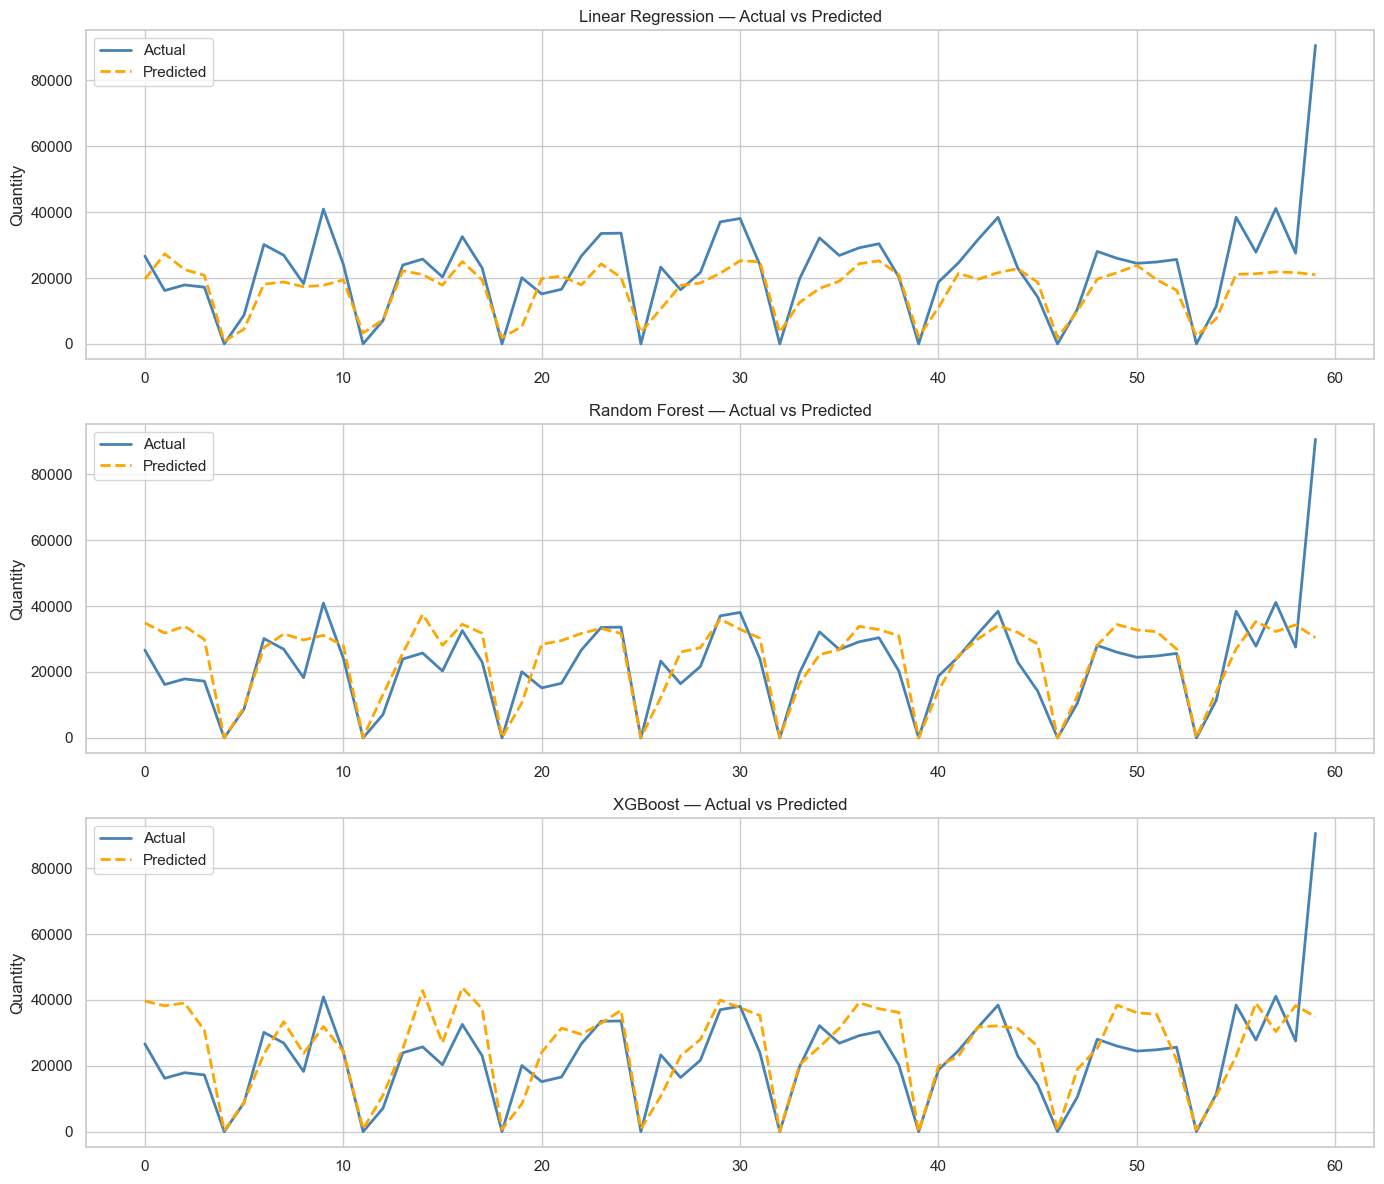

In [61]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, (name, result) in zip(axes, results.items()):
    ax.plot(y_test.values, label='Actual', color='steelblue', linewidth=2)
    ax.plot(result['predictions'], label='Predicted', color='orange', linewidth=2, linestyle='--')
    ax.set_title(f'{name} — Actual vs Predicted')
    ax.set_ylabel('Quantity')
    ax.legend()

plt.tight_layout()
plt.show()

## Model Observations

- All models successfully learned the weekly pattern (Saturday = 0)
- Random Forest best captures demand peaks and valleys
- The Dec 2011 spike (~90K units) was missed by all models
- Root cause: no seasonal/festival features yet
- Solution: Phase 4 adds holiday flags to improve spike prediction

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Build pipeline — scaler + best model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train pipeline on training data
pipeline.fit(X_train, y_train)

# Evaluate pipeline on test data
pipeline_preds = pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, pipeline_preds)
rmse = np.sqrt(mean_squared_error(y_test, pipeline_preds))
mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - pipeline_preds[mask]) / y_test[mask])) * 100

print(f"Pipeline MAE  : {mae:.0f}")
print(f"Pipeline RMSE : {rmse:.0f}")
print(f"Pipeline MAPE : {mape:.2f}%")

# Save pipeline and feature columns
joblib.dump(pipeline,     '../models/demand_pipeline.pkl')
joblib.dump(feature_cols, '../models/feature_cols.pkl')

print("\n✅ Pipeline saved → models/demand_pipeline.pkl")
print("✅ Features saved → models/feature_cols.pkl")

Pipeline MAE  : 6542
Pipeline RMSE : 10602
Pipeline MAPE : 32.03%

✅ Pipeline saved → models/demand_pipeline.pkl
✅ Features saved → models/feature_cols.pkl
